### High Frequency Words


##### Maxfield Raynolds
##### Data 620
##### Spring 2026

Import packages

In [1]:
import os
import zipfile
import requests
import nltk, re, pprint
from nltk import word_tokenize

### 1. Choose a corpus of interest
#### The Film Corpus 2.0

The Film Corpus 2.0 is a corpus of the texts of the screenplays of 1.068 films scraped from the Internet Moved Screenplay Database. It was acquired from UC Santa Cruz School of Engineering.

The following code extracts and compiles the text of all screenplays into a single string.

In [2]:
with zipfile.ZipFile('imsdb_raw_nov_2015.zip') as z:
    z.extractall('imsdb')

corpus = []
for root, dirs, files in os.walk('imsdb'):
    for file in files:
        if file.endswith('.txt'):
            with open(os.path.join(root, file), 'r', encoding = 'utf-8') as f:
                corpus.append(f.read())

screenplays = ' '. join(corpus)

### 2. How manyu total unique words are in the corpus?

The corpus was tokenized as lower case words.

In [63]:
tokens = word_tokenize(screenplays.lower())

There are more than 83 million tokens.

In [65]:
len(tokens)

83711893

Of the more than 83 million tokens, only 201,595 are unique but that includes punctuation.

In [66]:
len(set(tokens))

201595

The tokens are then reduced by eliminating punctuation marks.

In [68]:
tokens_no_punct = [w for w in tokens if w.isalpha()]

After eliminating punctuation there are now more than 65 million tokens, however this is still about 18 million fewer.

In [70]:
len(tokens_no_punct)

65173319

Stop words are loaded from NLTK.

In [69]:
from nltk.corpus import stopwords

stops = set(stopwords.words('english'))
len(stops)

198

Also, a custom stop word list is created that specifically relates to words and common abbreviations in screenplays.

In [81]:
common_screenplay_words = ['int','ext','cut','cont', 'camera']

Then the two lists of stop words are removed from the list of tokens.

In [82]:
final_words = []

for word in tokens_no_punct:
    if word not in stops:
        if word not in common_screenplay_words:
            final_words.append(word)

In the final set of tokens there are just under 36 million tokens.

In [83]:
len(final_words)

35945983

Among the 36 million tokens that are only 122,234 unique tokens in the corpus.

In [89]:
len(set(final_words))

122234

### 3. Taking the most common words, how many unique words represent half of the total words in the corpus?

The tokens are used to create a frequency distribution.

In [84]:
fd = nltk.FreqDist(final_words)

In [85]:
len(fd)

122234

Approximately 2,467 words represent about half of all words in the corpus.

In [93]:
count = 0
words = 0
half_all_words = len(final_words) / 2

for key, value in fd.items():
    if count <= half_all_words:
        count += value
        words += 1

print(count)
print(words)

17974231
2467


### 4. Identify the 200 highest frequency words in this corpus.

Below the code shows the 200 highest frequency words in the corpus.

In [86]:
top200 = [word for word in fd.most_common(200)]
top200

[('back', 225663),
 ('one', 176514),
 ('looks', 171164),
 ('like', 165702),
 ('day', 159439),
 ('know', 150369),
 ('night', 141047),
 ('get', 135456),
 ('see', 134225),
 ('door', 129542),
 ('room', 125220),
 ('man', 120032),
 ('around', 107107),
 ('go', 105899),
 ('right', 104035),
 ('got', 102294),
 ('look', 101256),
 ('away', 93480),
 ('two', 93318),
 ('turns', 91560),
 ('eyes', 87017),
 ('face', 85237),
 ('time', 84510),
 ('continued', 82779),
 ('head', 81737),
 ('hand', 81499),
 ('car', 80279),
 ('going', 80088),
 ('want', 77864),
 ('come', 74709),
 ('think', 73969),
 ('way', 70959),
 ('something', 70186),
 ('behind', 69967),
 ('well', 68303),
 ('takes', 67693),
 ('still', 66772),
 ('good', 63836),
 ('ca', 63714),
 ('little', 63318),
 ('house', 62897),
 ('us', 61279),
 ('oh', 61128),
 ('would', 61001),
 ('another', 59275),
 ('open', 57955),
 ('take', 57839),
 ('let', 57287),
 ('looking', 56659),
 ('hands', 56219),
 ('could', 55957),
 ('front', 55950),
 ('pulls', 55183),
 ('beat', 5

### 5. Create a graph that show the relative frequency of these 200 words.

<Axes: title={'center': 'Top 200 most frequent words in The Film Corpus 2'}, xlabel='Samples', ylabel='Counts'>

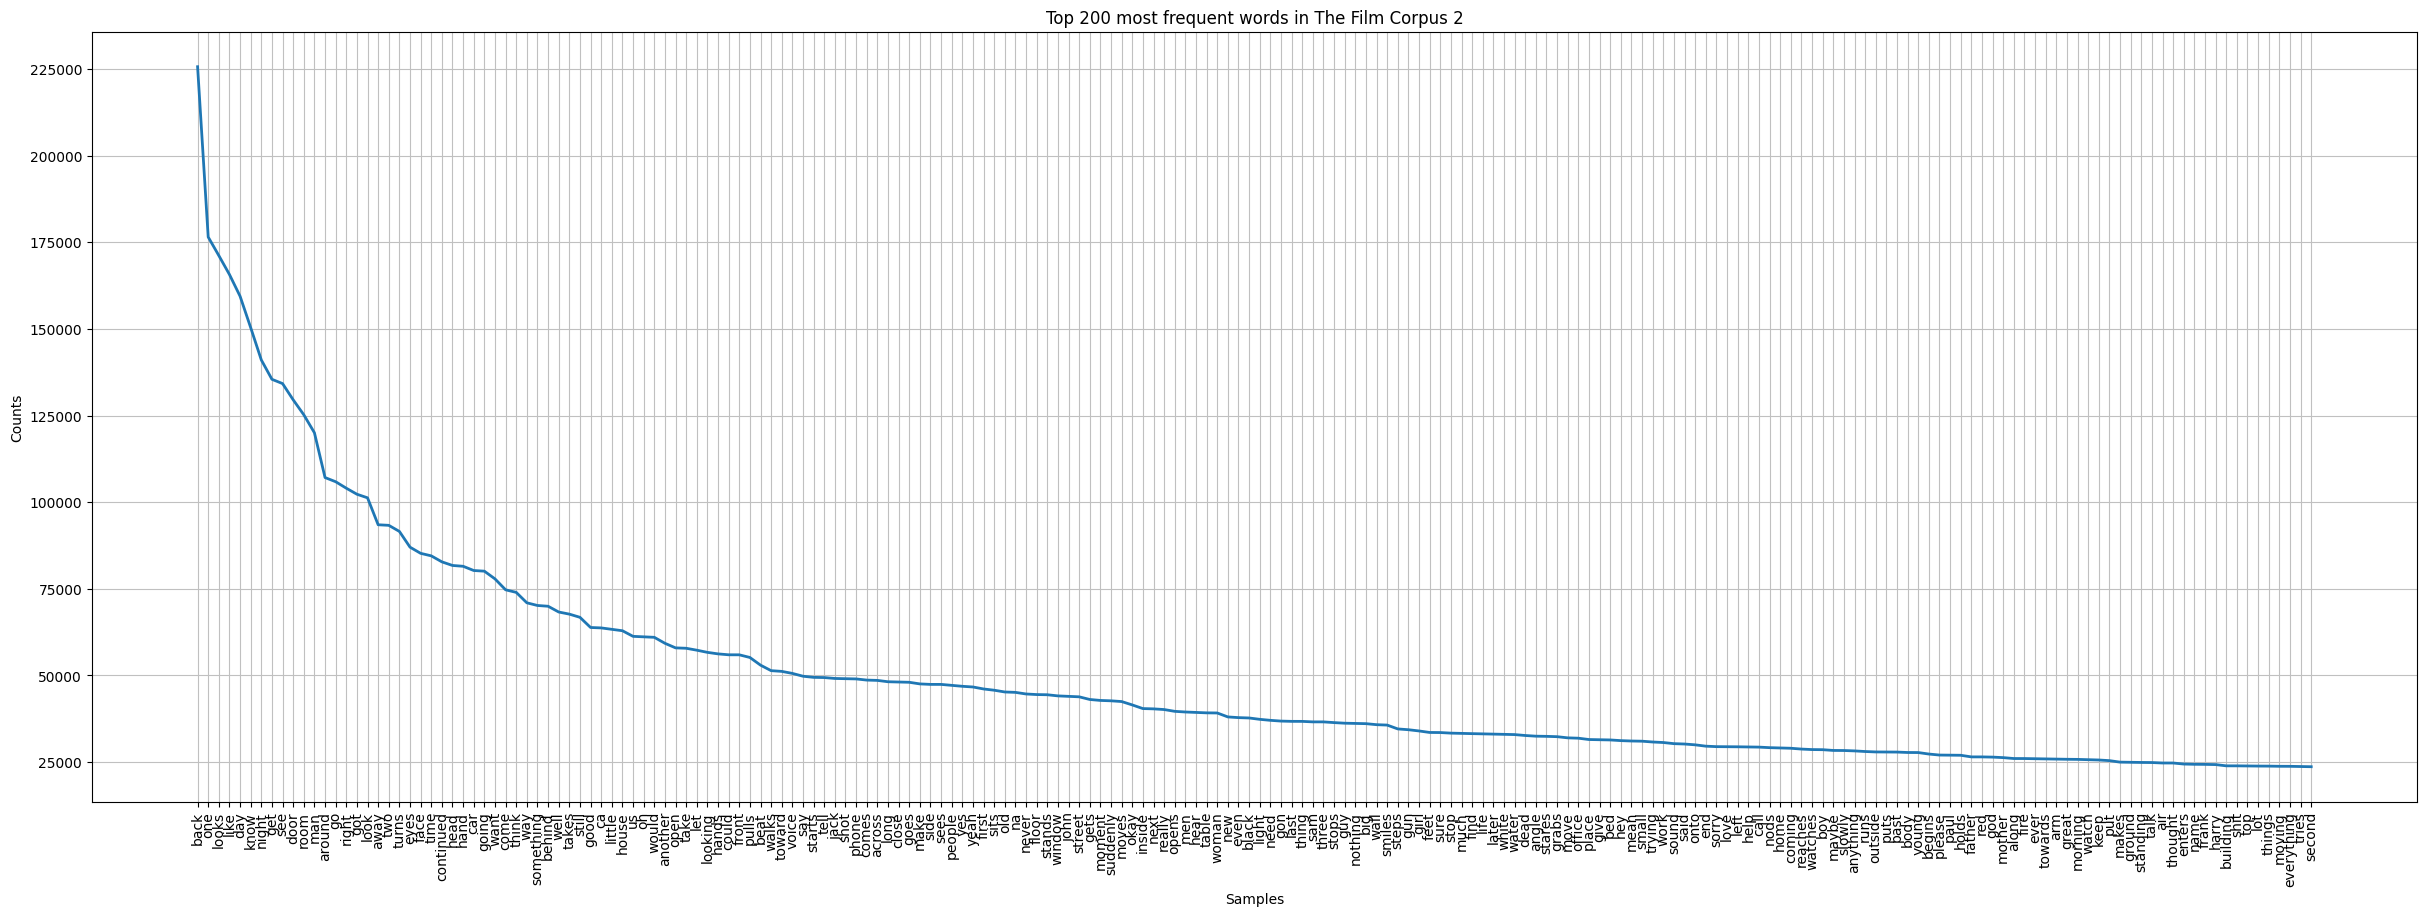

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 10))
fd.plot(200, title = 'Top 200 most frequent words in The Film Corpus 2')

### 6. Does the observed relative frequency of these words follow Zipf's law? Explain.

Zipf's law states "that when a set of measured values is sorted in decreasing order, the value of the n-th entry is often approximately inversely proportional to n. In other words, if words are sorted in descending order of frequency, the second most common word will appear half as often as the first word, and the third word will appear one third as often as the first word, and so on.

In [113]:
import pandas as pd

df = pd.DataFrame(top200, columns = ['words', 'count'])

In [117]:
df['Zipf_pct'] = 1/ (df.index + 1)
df['Zipf_ratio'] = df['count'] / df['count'][0]

In [118]:
df

,words,count,Zipf_pct,Zipf_ratio
0,back,225663,1.000000,1.000000
1,one,176514,0.500000,0.782202
2,looks,171164,0.333333,0.758494
3,like,165702,0.250000,0.734290
4,day,159439,0.200000,0.706536
...,...,...,...,...
195,things,23831,0.005102,0.105604
196,moving,23783,0.005076,0.105392
197,everything,23770,0.005051,0.105334
198,tries,23698,0.005025,0.105015


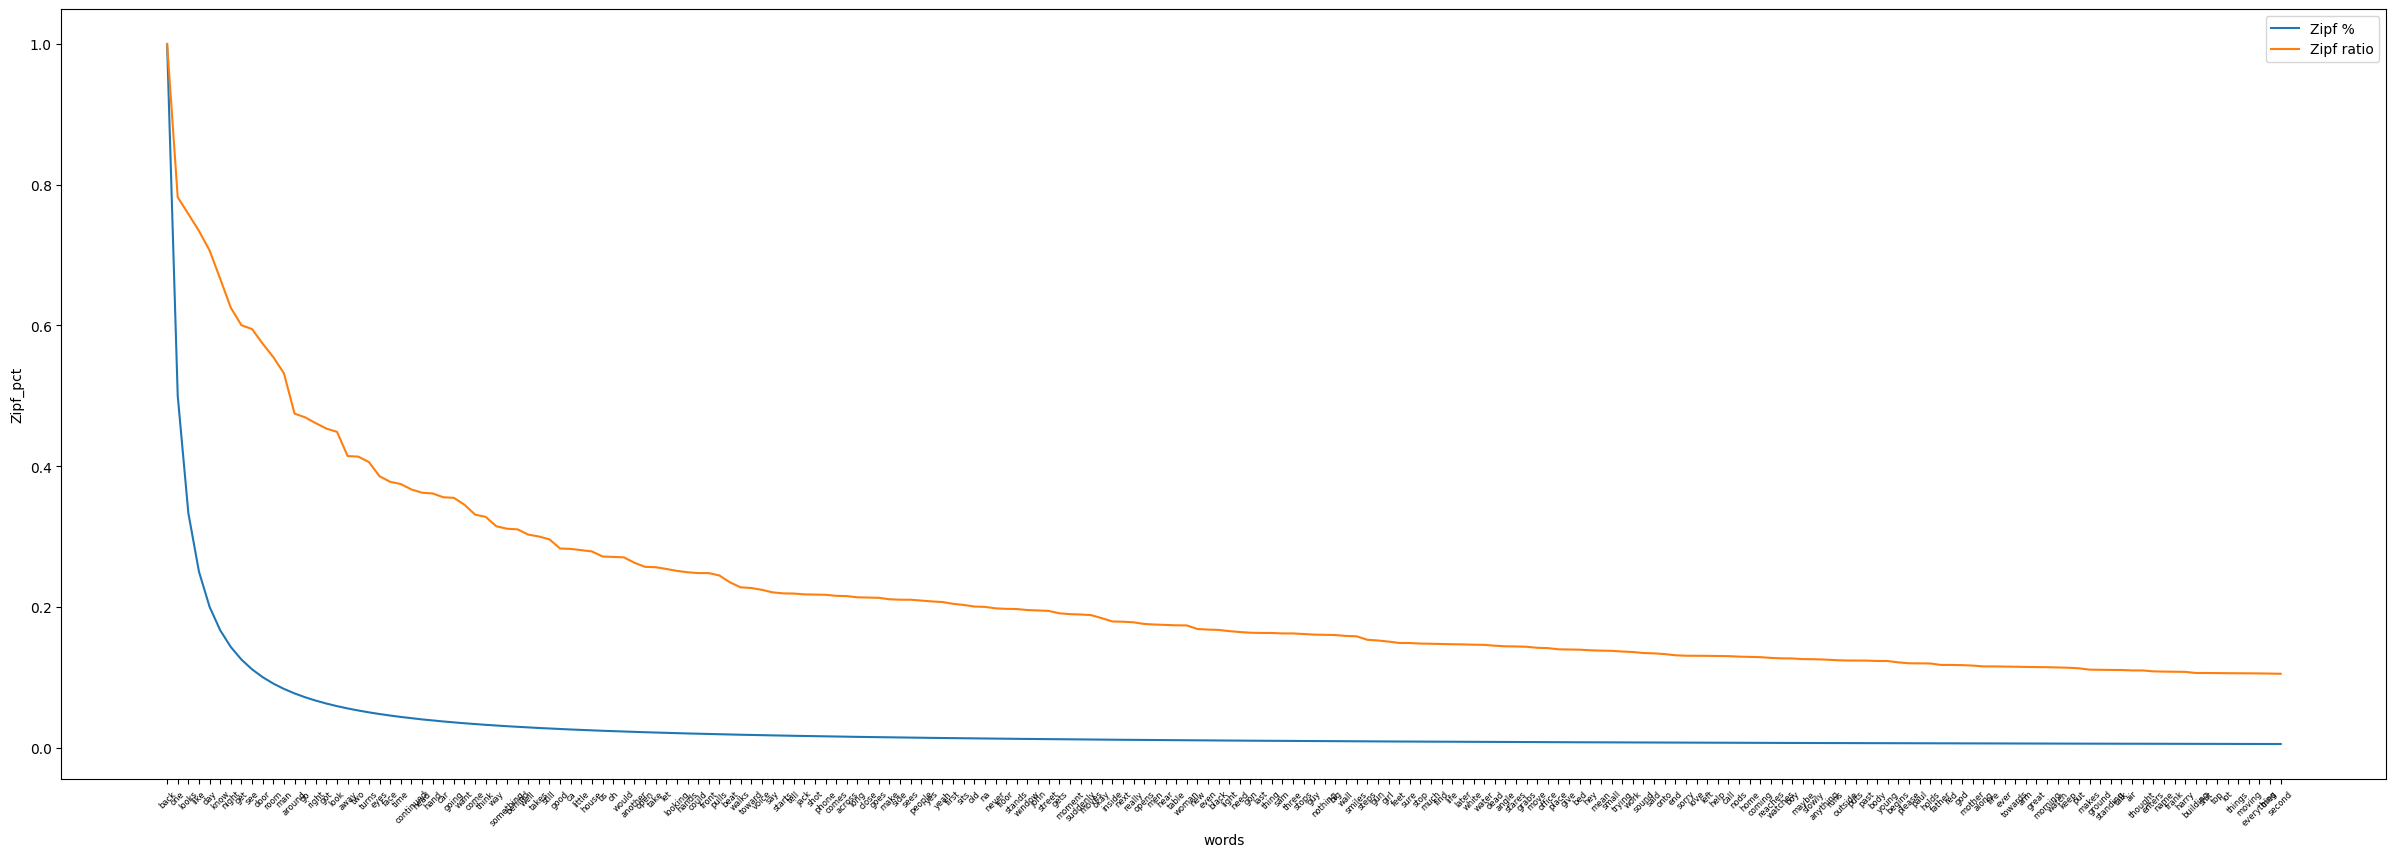

In [126]:
plt.figure(figsize=(30, 10))
sns.lineplot(df, x='words', y='Zipf_pct', label='Zipf %')
sns.lineplot(df, x='words', y='Zipf_ratio', label='Zipf ratio')
plt.xticks(fontsize=6, rotation=45)
plt.legend()

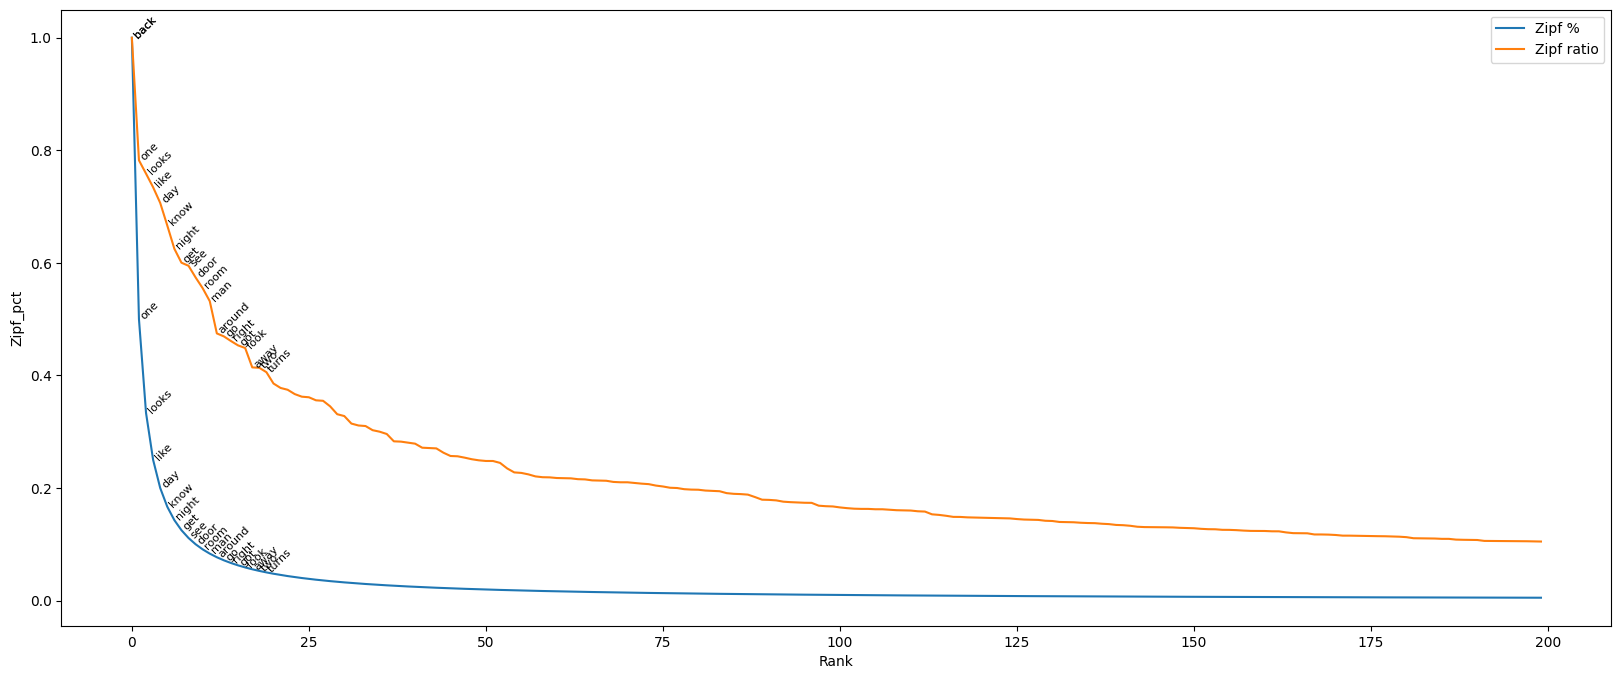

In [129]:
plt.figure(figsize=(20, 8))
sns.lineplot(data=df.reset_index(), x='index', y='Zipf_pct', label='Zipf %')
sns.lineplot(data=df.reset_index(), x='index', y='Zipf_ratio', label='Zipf ratio')

# annotate just the top 20 words
for i, row in df.head(20).iterrows():
    plt.annotate(row['words'], (i, row['Zipf_pct']), rotation=45, fontsize=8)
    plt.annotate(row['words'], (i, row['Zipf_ratio']), rotation=45, fontsize=8)

plt.xlabel('Rank')
plt.legend()

Inspecting the ratios of the word use and the expected ratios based on Zipf's law, the corpus, does not exactly follow Zipf's law. The most common words are used at a rate greater than expected by Zipf's law.

### 7. In what ways do you think the frequency of the words in this corpus differ from "all words in all corpora."

Inspecting the top 200 words, and thinking about how they do not align well with Zipf's law, it is highly likely that these words are more common as a result of the corpus being all screenplays for films. Inherent in film making is the need for scene descriptions, action lines, and sluglines. These often makeup a relatively large portion of the text in a screenplay and are a necessary element to help the production understand what a scene is about. Words like back, looks, like, day, night, get, door, room, have the potential to be used to describe the scene about to take place. As a result these words will appear more frequently than they would likely appear in all corpora in aggregate. The more than 1000 film scripts analyzed here would all have scene descriptions that are written in a similar way, but their dialogue may be very different. A sci-fi film won't use the same words in dialogue that a period drama will, but they will use the same scene description words. Therefore, the scene descriptions will have more frequently used language than dialogue might. As a result this corpus will have a higher frequency usage of those words.